# [프로젝트] 개 분류

In [56]:
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# 닥스훈트의 길이와 높이 데이터
dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

# 사모예드의 길이와 높이 데이터
samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_height = [56, 57, 50, 53, 60, 53, 49, 61]

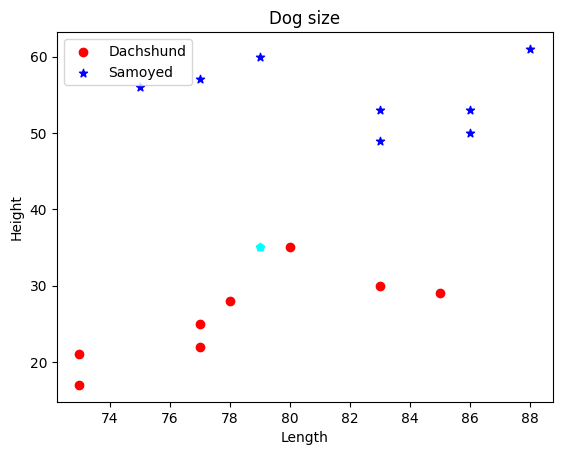

In [12]:
plt.scatter(dach_length, dach_height, c='red', label='Dachshund')
plt.scatter(samo_length, samo_height, c='blue', marker='*', label='Samoyed')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper left')

plt.scatter([79], [35], c='cyan', marker='p')  # 학습을 시켜본다. 모델은 knn을 사용해보자.
plt.show()

In [16]:
dach_data = np.column_stack((dach_length, dach_height))
print(dach_data)
print(dach_data.shape)
dach_target = [0] * 8 # 닥스훈트의 분류를 0으로 만든다.
print(dach_target)

samo_data = np.column_stack((samo_length, samo_height))
print(samo_data)
print(samo_data.shape)
samo_target = [1] * 8 # 사모예드의 분류를 0으로 만든다.
print(samo_target)

[[77 25]
 [78 28]
 [85 29]
 [83 30]
 [73 21]
 [77 22]
 [73 17]
 [80 35]]
(8, 2)
[0, 0, 0, 0, 0, 0, 0, 0]
[[75 56]
 [77 57]
 [86 50]
 [86 53]
 [79 60]
 [83 53]
 [83 49]
 [88 61]]
(8, 2)
[1, 1, 1, 1, 1, 1, 1, 1]


In [19]:
# 닥스랑 사모 데이타를 합치고, 섞어준다. 
dogs = np.concatenate((dach_data, samo_data))
print(dogs)
print(dogs.shape)

labels = np.concatenate((dach_target, samo_target))
print(labels)
print(labels.shape)

[[77 25]
 [78 28]
 [85 29]
 [83 30]
 [73 21]
 [77 22]
 [73 17]
 [80 35]
 [75 56]
 [77 57]
 [86 50]
 [86 53]
 [79 60]
 [83 53]
 [83 49]
 [88 61]]
(16, 2)
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
(16,)


In [20]:
knn = KNeighborsClassifier(3)
knn.fit(dogs, labels)  #학습시킨다.

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [21]:
unknown_dog = [[79, 35]]
print(knn.predict(unknown_dog))

[0]


In [35]:
# 닥스훈트 길이 200개 만들기
dach_length_mean = sum(dach_length) / len(dach_length)
print(dach_length_mean)

new_dach_length = np.random.normal(loc=78.25, scale=5.0, size=(200,))
print(new_dach_length.shape)

# 닥스훈트 높이 200개 만들기
dach_height_mean = sum(dach_height) / len(dach_height)
print(dach_height_mean)

new_dach_height = np.random.normal(loc=25.88, scale=5.0, size=(200,))
print(new_dach_height.shape)

# 사모예드 길이 200개 만들기 --------
samo_length_mean = sum(samo_length) / len(samo_length)
print(samo_length_mean)

new_samo_length = np.random.normal(loc=82.13, scale=5.0, size=(200,))
print(new_samo_length.shape)

# 사모예드 높이 200개 만들기
samo_height_mean = sum(samo_height) / len(samo_height)
print(dach_height_mean)

new_samo_height = np.random.normal(loc=25.88, scale=5.0, size=(200,))
print(new_samo_height.shape)

78.25
(200,)
25.875
(200,)
82.125
(200,)
25.875
(200,)


In [39]:
new_dach_data = np.column_stack((new_dach_length, new_dach_height))
print(new_dach_data)
print(new_dach_data.shape)
new_dach_target = [0] * 200 # 닥스훈트의 분류를 0으로 만든다.
print(new_dach_target)

new_samo_data = np.column_stack((new_samo_length, new_samo_height))
print(new_samo_data)
print(new_samo_data.shape)
new_samo_target = [1] * 200 # 사모예드의 분류를 0으로 만든다.
print(new_samo_target)

[[87.83830435 29.90065296]
 [83.82046273 24.86557977]
 [92.08621468 28.29174219]
 [83.4152699  32.23006392]
 [77.22904121 27.82142328]
 [79.18533786 24.96902887]
 [81.44626884 32.12806812]
 [74.75069954 23.090529  ]
 [74.8175468  28.2249693 ]
 [77.94094766 21.29686727]
 [77.71991929 30.90562472]
 [74.4659096  27.44547404]
 [73.39005811 29.84667784]
 [74.91920561 29.56603099]
 [70.35775613 23.78494817]
 [73.1048697  24.95722712]
 [69.9819682  19.62627557]
 [73.96787102 24.31692561]
 [86.40697244 15.5715254 ]
 [76.81000685 15.61708912]
 [78.47940592 34.39502788]
 [70.76076994 26.78644591]
 [72.35160685 23.72067428]
 [81.45492305 28.69422856]
 [82.86479292 25.16694911]
 [77.64951617 25.16799736]
 [99.22874726 26.00092418]
 [76.65295918 29.38191861]
 [77.12856736 26.46864929]
 [74.69681326 20.81124338]
 [75.11465185 35.07385104]
 [84.39821791 24.99263702]
 [80.56822355 21.39593806]
 [85.24985882 23.49761854]
 [82.48156372 25.53272371]
 [78.8428822  32.10539012]
 [82.75034187 30.73607514]
 

In [40]:
# 닥스랑 사모 데이타를 합치고, 섞어준다. 
new_dogs = np.concatenate((new_dach_data, new_samo_data))
print(new_dogs)
print(new_dogs.shape)

new_labels = np.concatenate((new_dach_target, new_samo_target))
print(new_labels)
print(new_labels.shape)

[[87.83830435 29.90065296]
 [83.82046273 24.86557977]
 [92.08621468 28.29174219]
 [83.4152699  32.23006392]
 [77.22904121 27.82142328]
 [79.18533786 24.96902887]
 [81.44626884 32.12806812]
 [74.75069954 23.090529  ]
 [74.8175468  28.2249693 ]
 [77.94094766 21.29686727]
 [77.71991929 30.90562472]
 [74.4659096  27.44547404]
 [73.39005811 29.84667784]
 [74.91920561 29.56603099]
 [70.35775613 23.78494817]
 [73.1048697  24.95722712]
 [69.9819682  19.62627557]
 [73.96787102 24.31692561]
 [86.40697244 15.5715254 ]
 [76.81000685 15.61708912]
 [78.47940592 34.39502788]
 [70.76076994 26.78644591]
 [72.35160685 23.72067428]
 [81.45492305 28.69422856]
 [82.86479292 25.16694911]
 [77.64951617 25.16799736]
 [99.22874726 26.00092418]
 [76.65295918 29.38191861]
 [77.12856736 26.46864929]
 [74.69681326 20.81124338]
 [75.11465185 35.07385104]
 [84.39821791 24.99263702]
 [80.56822355 21.39593806]
 [85.24985882 23.49761854]
 [82.48156372 25.53272371]
 [78.8428822  32.10539012]
 [82.75034187 30.73607514]
 

In [48]:
new_X = new_dogs
new_y = new_labels
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, new_y, test_size=0.2, random_state=1150) # 데이터를 나눈다
print(new_X_train.shape)
print(new_y_train.shape)

(320, 2)
(320,)


In [80]:
new_knn = KNeighborsClassifier(11)
new_knn.fit(new_dogs, new_labels)  #학습시킨다.

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [83]:
new_y_predict = new_knn.predict(new_X_test)
print(new_y_predict)  # 예측값 출력
print(new_y_test)   # 정답값 출력

# 귀찮으니까 정답확률을 계산한다.
new_scores = metrics.accuracy_score(new_y_test, new_y_predict)
print(new_scores * 100)

[0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 1 1 0 1
 1 1 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0
 0 0 0 0 0 1]
[1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 1 1
 1 1 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 1
 0 0 0 0 0 0]
63.74999999999999


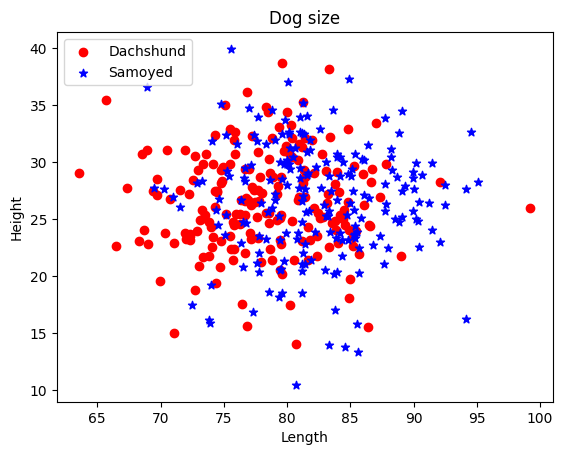

In [82]:
plt.scatter(new_dach_length, new_dach_height, c='red', label='Dachshund')
plt.scatter(new_samo_length, new_samo_height,c='blue',marker='*', label='Samoyed')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper left')

plt.show()